# 6.4 — Principal Component Analysis (PCA)

## The Analogy

Imagine you're preparing for Class 12 boards. You have **50 chapters** to study. But a smart friend analyses them and says:

> *"Chapters 3, 7, and 12 all teach the same core idea. Chapters 5 and 9 are nearly identical. Chapter 40 adds nothing new. Forget the 50 chapters — here are 10 core ideas that capture 95% of everything."*

You went from **50 dimensions → 10 dimensions** and lost almost nothing important. That's PCA.

---

## What Problem Does PCA Solve?

In ML, datasets often have **many features** — 50, 100, even 500 columns. This causes:
- Models train slowly
- Many features are **correlated** (height and weight both carry similar info about body size)
- Impossible to visualise data in 50 dimensions
- Too many features → overfitting risk

PCA compresses features into **fewer new features called Principal Components** — while keeping as much **variance (information)** as possible.

---

## Key Insight — Information = Variance

- A feature with the **same value for everyone** → zero variance → tells you nothing
- A feature that **varies a lot** across people → high variance → carries real information

PCA finds the directions in your data where **variance is maximum** and keeps those.

---

## What is a Principal Component?

A PC is **not** one of your original features. It's a **new direction** — a weighted combination of all original features.

```
PC1 = 0.6×price + 0.5×rooms + 0.3×distance + 0.4×age + ...
```

- **PC1** = direction of maximum variance
- **PC2** = direction of second most variance, perpendicular to PC1
- **PC3** = third most variance, perpendicular to PC1 and PC2
- ...and so on

**Interpretability tradeoff:** You can't say "PC1 = price". It's a mix of everything. You gain compression, you lose explainability.

---

## What PCA Computes — Step by Step

1. **Standardise** the data (mandatory — explained below)
2. **Compute Covariance Matrix** — measures how every feature varies with every other feature
3. **Find Eigenvectors and Eigenvalues**
   - Eigenvector = a direction in your data
   - Eigenvalue = how much variance exists in that direction
4. **Rank by eigenvalue** — highest variance direction = PC1, next = PC2, ...
5. **Pick top N components** — enough to explain 95% of variance (your choice)
6. **Transform data** — project original features onto chosen components

---

## Why StandardScaler is MANDATORY Before PCA

PCA measures variance. If `price_lakhs` ranges from 40–200 and `num_rooms` ranges from 1–4:
- Price variance dominates just because of **scale**, not because it's more informative
- PCA gets biased toward high-scale features
- StandardScaler brings all features to mean=0, std=1 → fair comparison

**Rule:** Always StandardScaler → PCA. Never skip.

---

## Is PCA Supervised or Unsupervised?

**Unsupervised.** PCA never looks at labels (y). It only looks at features (X) and finds structure. That's why it's in Chapter 6.

PCA is a **dimensionality reduction** technique — a preprocessing step, not a predictor.

Pipeline in practice:
```
Raw data → StandardScaler → PCA → Any ML Model → Prediction
```

---

## Train/Test Rule — Same as StandardScaler

- **Split first**
- **Fit PCA on training data only** → learns components from training patterns
- **Transform both train and test** using components learned from train
- Fitting on full dataset = test data influences components = **data leakage**

---

## Real World Problem — Chennai IT Company Employee Data

**Scenario:** Meena works in HR at a Chennai IT company. She has data on **500 employees** with **8 features**:

| Feature | Description |
|---|---|
| `years_experience` | Total years of work experience |
| `age` | Age of employee |
| `num_projects` | Projects completed |
| `training_hours` | Hours of training attended |
| `team_size` | Size of their current team |
| `manager_rating` | Rating given by manager (1–10) |
| `peer_rating` | Rating given by peers (1–10) |
| `self_rating` | Self-assessment rating (1–10) |

**Target:** `salary_lakhs` — predict salary

**Problem Meena has:**
- `years_experience` and `age` are highly correlated — older employees tend to have more experience
- `manager_rating`, `peer_rating`, `self_rating` are also correlated — if you're good, all three are high
- 8 features isn't huge, but it demonstrates PCA perfectly

**What we'll do:**
1. First try Linear Regression with all 8 features
2. Apply PCA to compress 8 features → fewer components
3. Run Linear Regression on PCA-transformed data
4. Compare results — did we lose much by compressing?

In [1]:
# Import everything we need
# numpy and pandas — data handling
# sklearn modules — split, scale, PCA, model, metrics
# matplotlib and seaborn — visualisation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA          # PCA lives in decomposition, not linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# For reproducibility — same random numbers every run
np.random.seed(42)

---
## Step 1 — Create Meena's Employee Dataset

In [2]:
n = 500  # 500 employees

# years_experience is the base — many features will correlate with it
# This intentional correlation is exactly why PCA will help
years_experience = np.random.randint(1, 25, n)

# age correlates with experience — older = more experienced (with some noise)
age = years_experience + np.random.randint(22, 28, n)

# num_projects loosely grows with experience but has randomness
num_projects = years_experience * 2 + np.random.randint(0, 10, n)

# training_hours — somewhat independent, varies by person
training_hours = np.random.randint(10, 200, n)

# team_size — mostly independent of experience
team_size = np.random.randint(3, 20, n)

# All three ratings correlate with each other — a high performer gets high from everyone
base_performance = np.random.uniform(4, 10, n)
manager_rating = np.clip(base_performance + np.random.normal(0, 0.5, n), 1, 10)
peer_rating    = np.clip(base_performance + np.random.normal(0, 0.7, n), 1, 10)
self_rating    = np.clip(base_performance + np.random.normal(0, 1.0, n), 1, 10)

# Salary — driven by experience, projects, and manager rating
salary_lakhs = (
    5
    + years_experience * 1.2
    + num_projects * 0.3
    + manager_rating * 1.5
    + training_hours * 0.05
    + np.random.normal(0, 3, n)   # real world noise
)

# Build the DataFrame
df = pd.DataFrame({
    'years_experience': years_experience,
    'age': age,
    'num_projects': num_projects,
    'training_hours': training_hours,
    'team_size': team_size,
    'manager_rating': manager_rating,
    'peer_rating': peer_rating,
    'self_rating': self_rating,
    'salary_lakhs': salary_lakhs
})

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (500, 9)


,years_experience,age,num_projects,training_hours,team_size,manager_rating,peer_rating,self_rating,salary_lakhs
0,7,30,17,25,16,7.978227,7.420291,7.192474,27.965252
1,20,42,45,193,18,6.094910,6.255907,5.038612,61.358196
2,15,40,35,130,12,9.086451,9.673787,8.535034,47.434804
3,11,35,22,19,12,9.486518,10.000000,9.707139,37.921783
4,8,33,23,167,14,9.108262,9.127909,9.375271,40.729040


---
## Step 2 — Explore Correlations

Before applying PCA, let's visually confirm that features are correlated.
High correlation between features = redundant information = PCA can compress without much loss.

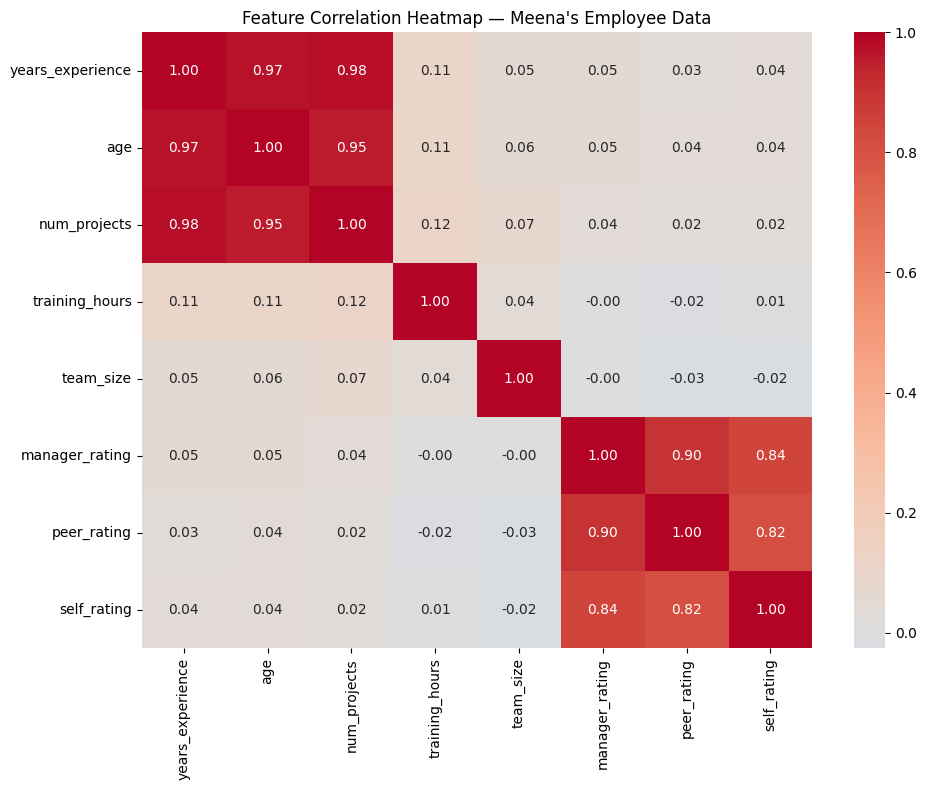

In [3]:
plt.figure(figsize=(10, 8))

# Correlation heatmap — shows how each feature moves with every other feature
# Values close to 1 or -1 = high correlation = redundancy = PCA opportunity
# Values close to 0 = independent features
sns.heatmap(
    df.drop('salary_lakhs', axis=1).corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title("Feature Correlation Heatmap — Meena's Employee Data")
plt.tight_layout()
plt.show()

# Notice:
# years_experience and age → high correlation (expected)
# years_experience and num_projects → high correlation (built that way)
# manager_rating, peer_rating, self_rating → correlated with each other

---
## Step 3 — Split the Data

**Split FIRST — before any scaling or PCA.**
If you scale or apply PCA before splitting, test data leaks into your transformations.

In [4]:
X = df.drop('salary_lakhs', axis=1)   # 8 features
y = df['salary_lakhs']                 # target

# 80% train, 20% test — standard split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (400, 8)
Test size:  (100, 8)


---
## Step 4 — Baseline: Linear Regression on All 8 Features

Always establish a baseline first. We'll compare PCA results against this.

In [5]:
# Scale first — mandatory before PCA, and good practice for LR too
# Fit ONLY on training data — test data must stay invisible during fitting
scaler_baseline = StandardScaler()
X_train_scaled = scaler_baseline.fit_transform(X_train)
X_test_scaled  = scaler_baseline.transform(X_test)    # transform only — no fit

# Train Linear Regression on all 8 features
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_scaled, y_train)

# Evaluate
y_pred_baseline = lr_baseline.predict(X_test_scaled)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline   = r2_score(y_test, y_pred_baseline)

print("=== Baseline: Linear Regression (8 features) ===")
print(f"RMSE : ₹{rmse_baseline:.2f} lakhs")
print(f"R²   : {r2_baseline:.4f}")

=== Baseline: Linear Regression (8 features) ===
RMSE : ₹3.09 lakhs
R²   : 0.9457


---
## Step 5 — Apply PCA and Explore Explained Variance

First, fit PCA keeping ALL components — so we can see how much variance each one explains.
This tells us how many components to keep.

In [6]:
# PCA — n_components=None means keep all components first
# We're doing this to inspect variance BEFORE deciding how many to keep
# Background: sklearn computes covariance matrix → eigendecomposition → sorts by eigenvalue
pca_full = PCA(n_components=None, random_state=42)

# Fit on TRAINING DATA ONLY — same rule as StandardScaler
# PCA learns the directions (eigenvectors) from training patterns only
pca_full.fit(X_train_scaled)

# explained_variance_ratio_ — what % of total variance each PC captures
evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)  # cumulative sum to find cutoff point

print("Explained Variance Ratio per Component:")
for i, (ev, cum) in enumerate(zip(evr, cumulative_evr)):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.1f}%)  |  Cumulative: {cum*100:.1f}%")

Explained Variance Ratio per Component:
  PC1: 0.3843 (38.4%)  |  Cumulative: 38.4%
  PC2: 0.3235 (32.3%)  |  Cumulative: 70.8%
  PC3: 0.1245 (12.4%)  |  Cumulative: 83.2%
  PC4: 0.1228 (12.3%)  |  Cumulative: 95.5%
  PC5: 0.0245 (2.4%)  |  Cumulative: 98.0%
  PC6: 0.0129 (1.3%)  |  Cumulative: 99.2%
  PC7: 0.0059 (0.6%)  |  Cumulative: 99.8%
  PC8: 0.0016 (0.2%)  |  Cumulative: 100.0%


---
## Step 6 — Scree Plot (Elbow Method for PCA)

Same elbow intuition you used in K-Means — look for where the curve flattens.
The elbow = point where adding more components gives diminishing returns.

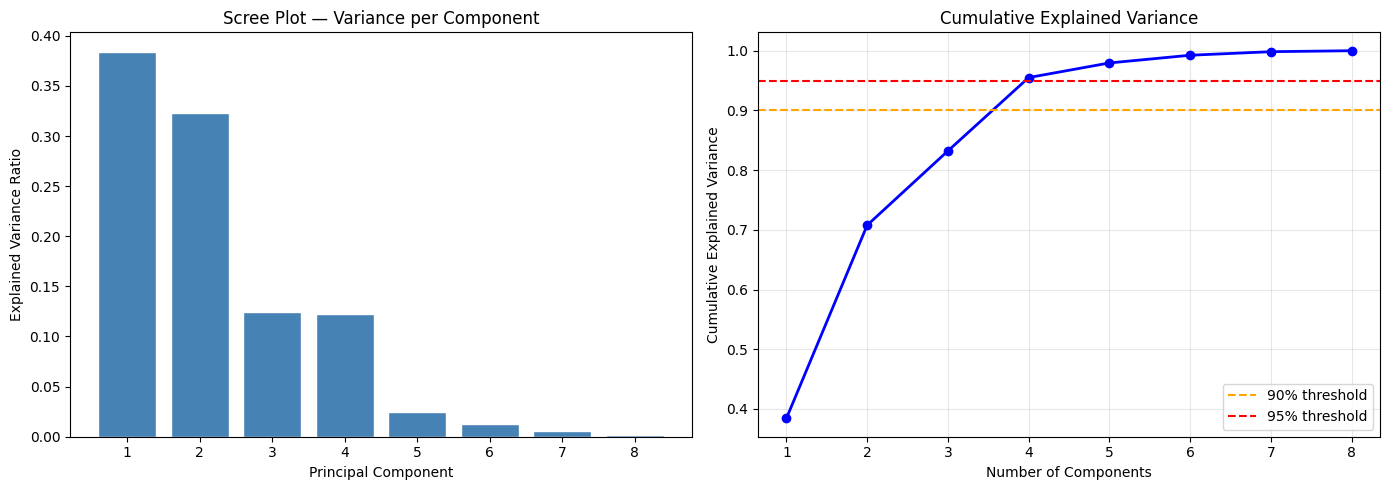

Components needed for 95% variance: 4


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — individual variance per component (scree plot)
# Look for the elbow — where the bars stop dropping sharply
axes[0].bar(
    range(1, len(evr)+1), evr,
    color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — Variance per Component')
axes[0].set_xticks(range(1, len(evr)+1))

# Right plot — cumulative variance
# The horizontal dashed lines mark the 90% and 95% thresholds
# Pick the N where cumulative line crosses your threshold
axes[1].plot(range(1, len(cumulative_evr)+1), cumulative_evr, 'bo-', linewidth=2)
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='red',    linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(cumulative_evr)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find how many components needed for 95%
n_components_95 = np.argmax(cumulative_evr >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

---
## Step 7 — Apply PCA with Chosen Components

Now we apply PCA keeping only the components that explain 95% of variance.
Everything from Step 4's scaler is reused here — same scaler, now feeding into PCA.

In [8]:
# Apply PCA keeping components that explain 95% of variance
# n_components=0.95 tells sklearn to automatically pick enough components for 95%
# Internally: fits covariance matrix, runs eigendecomposition, keeps top N eigenvectors
pca = PCA(n_components=0.95, random_state=42)

# Fit on training data only — PCA learns directions from train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test using the same directions learned from train — no fit here
X_test_pca  = pca.transform(X_test_scaled)

print(f"Original features : {X_train_scaled.shape[1]}")
print(f"After PCA         : {X_train_pca.shape[1]}")
print(f"Variance retained : {pca.explained_variance_ratio_.sum()*100:.1f}%")

Original features : 8
After PCA         : 4
Variance retained : 95.5%


---
## Step 8 — Linear Regression on PCA-Transformed Data

In [9]:
# Train same Linear Regression — but now on compressed PCA features
# The model has no idea these aren't original features — it just sees numbers
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))
r2_pca   = r2_score(y_test, y_pred_pca)

print("=== PCA + Linear Regression ===")
print(f"RMSE : ₹{rmse_pca:.2f} lakhs")
print(f"R²   : {r2_pca:.4f}")

=== PCA + Linear Regression ===
RMSE : ₹3.38 lakhs
R²   : 0.9351


---
## Step 9 — Visualise PCA in 2D

One of PCA's most powerful uses — compress to 2 components and **plot high-dimensional data**.
We can't see 8 dimensions, but we can see 2. Colour by salary to see if PCA captured meaningful structure.

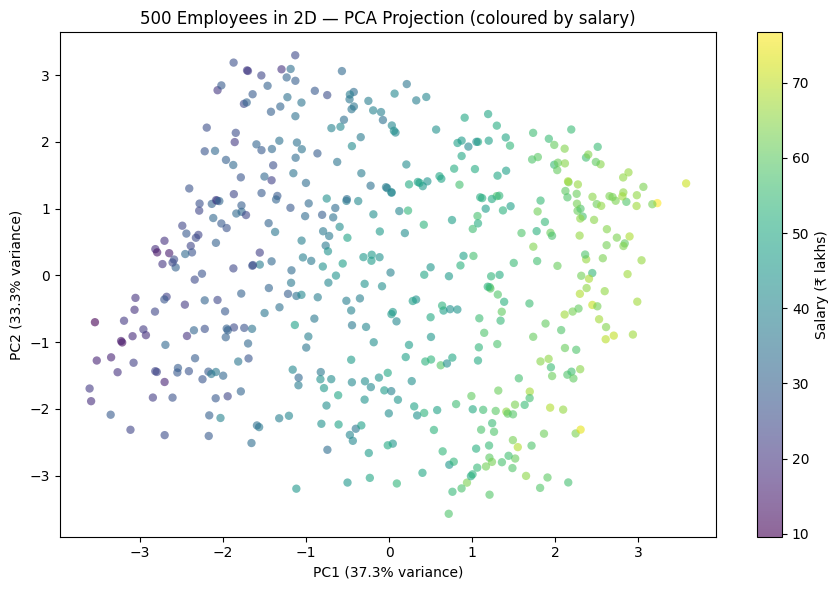

In [10]:
# Compress all 8 features to exactly 2 — purely for visualisation
# Not for modelling — just to see the structure PCA found
pca_2d = PCA(n_components=2, random_state=42)
X_all_scaled = scaler_baseline.transform(X)   # scale full dataset using train scaler
X_2d = pca_2d.fit_transform(X_all_scaled)      # compress to 2D

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],   # PC1 on x-axis, PC2 on y-axis
    c=y,                        # colour each point by salary
    cmap='viridis',
    alpha=0.6,
    edgecolors='none'
)
plt.colorbar(scatter, label='Salary (₹ lakhs)')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('500 Employees in 2D — PCA Projection (coloured by salary)')
plt.tight_layout()
plt.show()

# If you see a gradient from dark to light along PC1 — PCA captured salary-related structure

---
## Step 10 — Results Comparison

In [11]:
print("="*55)
print(f"{'Model':<30} {'RMSE':>10} {'R²':>10}")
print("-"*55)
print(f"{'LR — 8 original features':<30} {rmse_baseline:>9.2f}  {r2_baseline:>9.4f}")
print(f"{'LR — PCA compressed':<30} {rmse_pca:>9.2f}  {r2_pca:>9.4f}")
print("="*55)

variance_kept = pca.explained_variance_ratio_.sum() * 100
features_kept = X_train_pca.shape[1]
features_orig = X_train_scaled.shape[1]

print(f"\nPCA reduced {features_orig} features → {features_kept} components")
print(f"Variance retained: {variance_kept:.1f}%")
print(f"Variance lost:     {100-variance_kept:.1f}%")

Model                                RMSE         R²
-------------------------------------------------------
LR — 8 original features            3.09     0.9457
LR — PCA compressed                 3.38     0.9351

PCA reduced 8 features → 4 components
Variance retained: 95.5%
Variance lost:     4.5%


---
## Step 11 — Component Loadings (What Goes Into Each PC?)

Even though PCs aren't interpretable as single features, we can inspect which original features
contribute most to each PC. This is called the **loading matrix**.

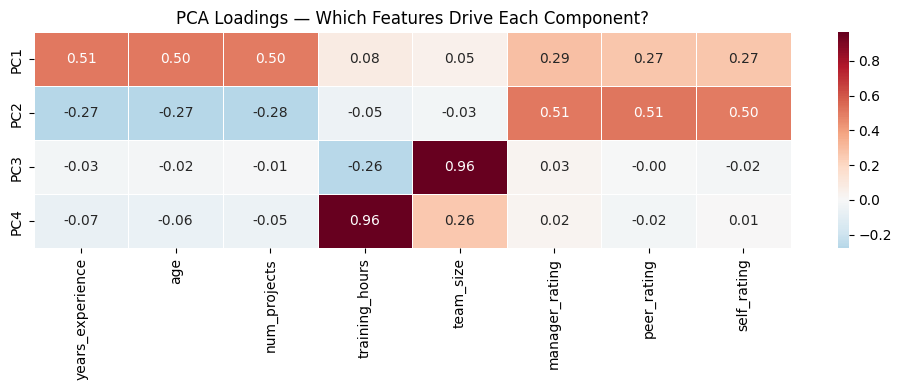

In [12]:
# pca.components_ — shape (n_components, n_features)
# Each row = one PC. Each value = weight of that original feature in this PC
# High absolute value = that feature contributes a lot to this PC

loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

plt.figure(figsize=(10, 4))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)
plt.title('PCA Loadings — Which Features Drive Each Component?')
plt.tight_layout()
plt.show()

# Red = strong positive contribution to this PC
# Blue = strong negative contribution
# White = near zero = this feature barely matters for this PC

---
## Summary

| Concept | Key Point |
|---|---|
| **What PCA does** | Compresses N features into fewer Principal Components keeping maximum variance |
| **Information = Variance** | High variance feature = informative. PCA keeps high variance directions |
| **Principal Component** | A new artificial direction = weighted combination of ALL original features |
| **Why StandardScaler mandatory** | PCA biased toward high-scale features without it |
| **Supervised or Unsupervised?** | Unsupervised — never looks at labels (y) |
| **Interpretability** | Lost — PC1 is a mix of everything, can't say "this = price" |
| **How many components** | Scree plot + cumulative variance — typically keep 90–95% |
| **Train/test rule** | Fit PCA on train only. Transform both with same components |
| **Best use cases** | Visualisation, preprocessing before ML, noise removal |
| **Avoid when** | Interpretability matters (can't explain PC1 to a client) |

---

## When to Use PCA

| Situation | Use PCA? |
|---|---|
| Many features, correlated | ✅ Yes |
| Want to visualise high-dimensional data | ✅ Yes |
| Model training too slow | ✅ Yes |
| Need to explain predictions to client | ❌ No |
| Few features, all independent | ❌ No need |
| Tree-based models (RF, XGBoost) | ❌ Rarely — they handle features well themselves |

---

## Practice Task

Try this yourself:

1. Change `n_components=0.95` to `n_components=0.80` — how many features does PCA keep now? Does RMSE get worse?
2. In the 2D scatter plot, do you see a gradient in salary along PC1? What does that tell you?
3. Look at the loadings heatmap — which original features contribute most to PC1?

```python
# YOUR CODE HERE — try n_components=0.80


# YOUR CODE HERE — print how many components were selected


# YOUR CODE HERE — compare RMSE with baseline

```